In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [2]:
pip install yfinance

In [3]:
import yfinance as yf
df = yf.download('AAPL', period='10y')
df.head()

/tmp/ipykernel_6004/3580625406.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('AAPL', period='10y')
[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2016-04-15,24.878878,25.433756,24.851701,25.390724,187756000
2016-04-18,24.342119,24.675044,24.219820,24.661456,243286000
2016-04-19,24.213020,24.459883,24.059014,24.432705,129539600
2016-04-20,24.262854,24.480275,24.020520,24.151879,122444000
2016-04-21,24.000143,24.217564,23.898226,24.217564,126210000


In [4]:
df.columns = ['Close', 'High', 'Low', 'Open', 'Volume']

In [5]:
df = df.reset_index()

In [6]:
df.shape

(2513, 6)

In [7]:
df = df.drop(['Date'], axis=1)

In [8]:
df

,Close,High,Low,Open,Volume
0,24.878878,25.433756,24.851701,25.390724,187756000
1,24.342119,24.675044,24.219820,24.661456,243286000
2,24.213020,24.459883,24.059014,24.432705,129539600
3,24.262854,24.480275,24.020520,24.151879,122444000
4,24.000143,24.217564,23.898226,24.217564,126210000
...,...,...,...,...,...
2508,258.899994,259.750000,256.529999,258.450012,41032800
2509,260.489990,261.119995,256.070007,259.000000,28121600
2510,260.480011,262.190002,259.019989,259.980011,31291500
2511,259.200012,260.179993,256.660004,259.730011,36234700


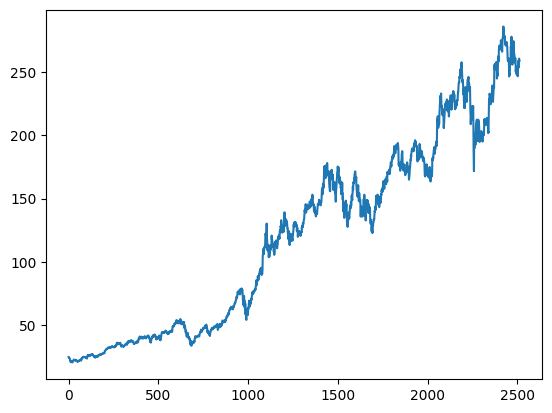

In [9]:
plt.plot(df.Close)

In [10]:
ma100 = df.Close.rolling(100).mean()
ma100

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2508,264.913530
2509,264.786286
2510,264.664138
2511,264.534584


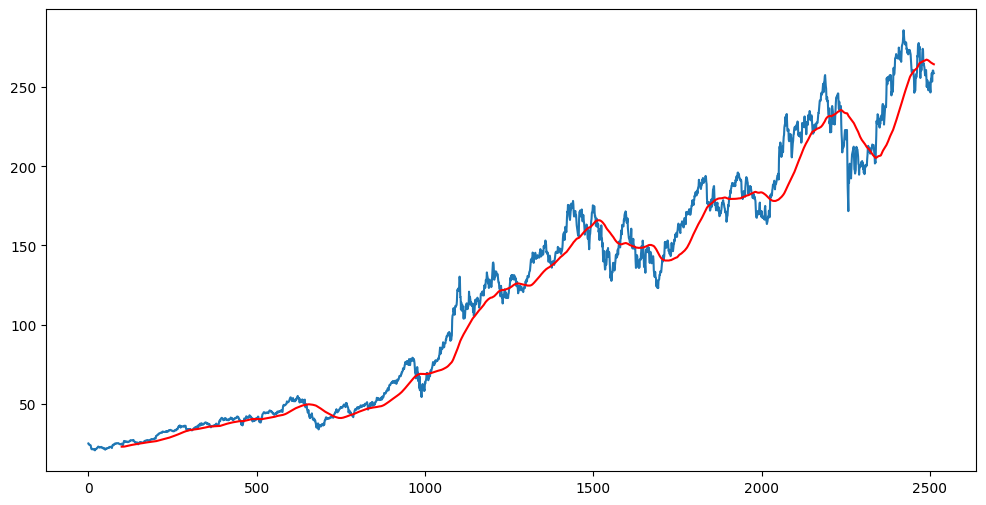

In [11]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')

In [12]:
ma200 = df.Close.rolling(200).mean()
ma200

,Close
0,NaN
1,NaN
2,NaN
3,NaN
4,NaN
...,...
2508,249.703167
2509,250.001173
2510,250.305112
2511,250.596369


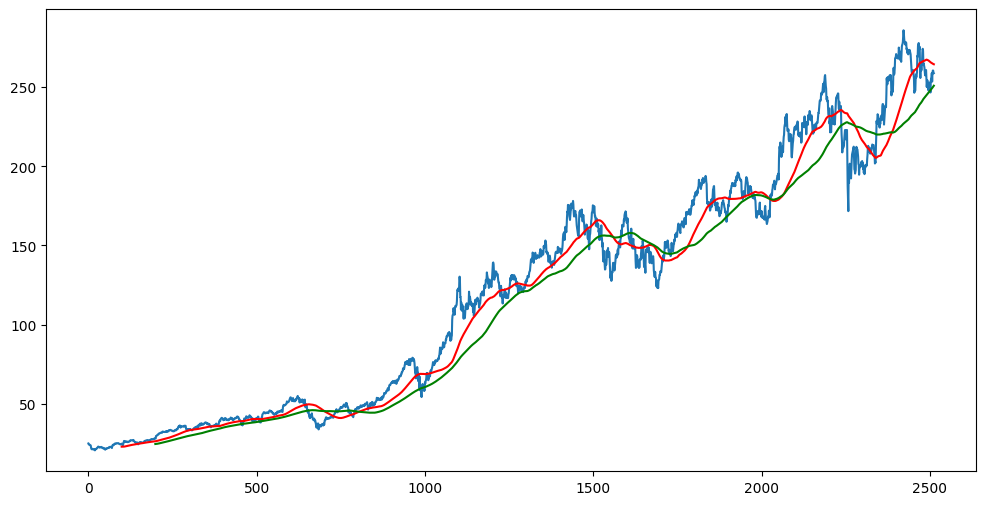

In [13]:
plt.figure(figsize=(12,6))
plt.plot(df.Close)
plt.plot(ma100,'r')
plt.plot(ma200,'g')

In [14]:
df.shape

(2513, 5)

In [15]:
#spiltting Data into Training and Testing

data_training = pd.DataFrame(df['Close'][0:int(len(df)*0.70)])
data_testing = pd.DataFrame(df['Close'][int(len(df)*0.70): int(len(df))])

In [16]:
print(data_training.shape, data_testing.shape)

print(data_training.head())
print(data_testing.head())

(1759, 1) (754, 1)
       Close
0  24.878878
1  24.342119
2  24.213020
3  24.262854
4  24.000143
           Close
1759  157.813721
1760  163.195770
1761  162.850769
1762  162.870468
1763  164.092758


In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler(feature_range=(0,1))

In [18]:
data_training_array = scaler.fit_transform(data_training)
data_training_array

array([[0.02726061],
       [0.02385302],
       [0.02303345],
       ...,
       [0.89972602],
       [0.88326797],
       [0.87557091]])

In [19]:
x_train = []
y_train = []

for i in range(100, data_training_array.shape[0]):
  x_train.append(data_training_array[i-100:i])
  y_train.append(data_training_array[i,0])

x_train, y_train = np.array(x_train), np.array(y_train)

#ML Model

In [20]:
!pip install tensorflow

In [21]:
from tensorflow.keras.layers import Dense, Dropout, LSTM
from tensorflow.keras.models import Sequential

In [22]:
model = Sequential()
model.add(LSTM(units = 50, activation = 'relu', return_sequences = True, input_shape = (x_train.shape[1],1)))
model.add(Dropout(0.2))

model.add(LSTM(units = 60, activation = 'relu', return_sequences = True))
model.add(Dropout(0.3))

model.add(LSTM(units = 80, activation = 'relu', return_sequences = True))
model.add(Dropout(0.4))

model.add(LSTM(units = 120, activation = 'relu'))
model.add(Dropout(0.5))

model.add(Dense(units = 1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [23]:
model.compile(optimizer='adam', loss='mean_squared_error')
model.fit(x_train, y_train, epochs=50)

Epoch 1/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 26s 252ms/step - loss: 0.0498
Epoch 2/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 254ms/step - loss: 0.0094
Epoch 3/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 252ms/step - loss: 0.0075
Epoch 4/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 253ms/step - loss: 0.0073
Epoch 5/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 253ms/step - loss: 0.0073
Epoch 6/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 251ms/step - loss: 0.0070
Epoch 7/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 253ms/step - loss: 0.0072
Epoch 8/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 14s 263ms/step - loss: 0.0066
Epoch 9/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 249ms/step - loss: 0.0061
Epoch 10/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step - loss: 0.0056
Epoch 11/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 251ms/step - loss: 0.0065
Epoch 12/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 251ms/step - loss: 0.0060
Epoch 13/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step - loss: 0.0053
Epoch 14/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 13s 250ms/step - loss: 0.0058
Epoch 15/50
52/52 ━━━━━━━━━━━━━━━━━━━━ 20s 

In [24]:
model.save('keras_model.h5')

In [25]:
data_testing.head()

,Close
1759,157.813721
1760,163.195770
1761,162.850769
1762,162.870468
1763,164.092758


In [26]:
past_100_days = data_training.tail(100)

In [27]:
final_df = pd.concat([past_100_days, data_testing], ignore_index=True)

In [28]:
final_df.head()

,Close
0,147.671921
1,146.441650
2,148.341202
3,148.902176
4,145.673950


In [29]:
input_data = scaler.fit_transform(final_df)
input_data

array([[1.51189663e-01],
       [1.43636230e-01],
       [1.55298816e-01],
       [1.58743003e-01],
       [1.38922817e-01],
       [1.52035720e-01],
       [1.57413725e-01],
       [1.39527076e-01],
       [1.16020906e-01],
       [9.75904231e-02],
       [1.39043575e-01],
       [1.40735783e-01],
       [1.37714204e-01],
       [1.30583846e-01],
       [1.08105010e-01],
       [9.62005322e-02],
       [1.06533654e-01],
       [1.03572875e-01],
       [1.17652313e-01],
       [1.23574339e-01],
       [1.09917789e-01],
       [6.93707460e-02],
       [5.73457907e-02],
       [4.44142585e-02],
       [4.39912767e-02],
       [6.30259255e-02],
       [4.35682950e-02],
       [4.13324404e-02],
       [3.02742538e-02],
       [6.16372993e-03],
       [2.77362694e-02],
       [2.96698536e-02],
       [3.02176689e-04],
       [8.09736094e-03],
       [0.00000000e+00],
       [2.77966954e-02],
       [3.09991312e-02],
       [3.45041185e-02],
       [5.11819671e-02],
       [5.06986530e-02],


In [30]:
x_test = []
y_test = []

for i in range(100, input_data.shape[0]):
  x_test.append(input_data[i-100:i])
  y_test.append(input_data[i,0])

In [31]:
x_test,y_test = np.array(x_test), np.array(y_test)
print(x_test.shape)
print(y_test.shape)

(754, 100, 1)
(754,)


In [32]:
y_predicted = model.predict(x_test)


24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 103ms/step


In [33]:
y_predicted.shape

(754, 1)

In [34]:
scaler.scale_

array([0.00613965])

In [35]:
scale_factor = 1/0.00613965
y_predicted = y_predicted * scale_factor
y_test = y_test * scale_factor

<function matplotlib.pyplot.legend(*args, **kwargs) -> 'Legend'>

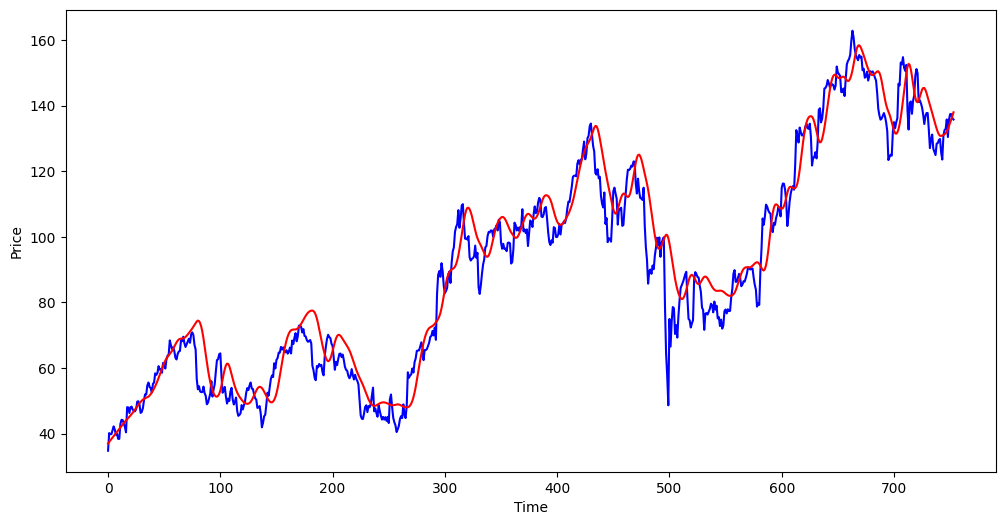

In [36]:
plt.figure(figsize=(12,6))
plt.plot(y_test, 'b', label = 'Original Price')
plt.plot(y_predicted, 'r', label = 'Predicted Price')
plt.xlabel('Time')
plt.ylabel('Price')
plt.legend